# CTable Tutorial

**CTable** is a columnar compressed table built on top of `blosc2.NDArray`.
It stores each column independently as a compressed array, giving you:

- **Compression** — data lives compressed in RAM and on disk.
- **Schema** — every column has a declared type and optional constraints.
- **Speed** — bulk operations stay in NumPy; no row-by-row Python overhead.
- **Persistence** — tables can be saved to and loaded from disk transparently.

This notebook walks through the full API, starting from the very basics and finishing with a real-world analysis of climate data across ten world cities.

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

import blosc2
from blosc2 import CTable

---
## Part 1 — The Basics

### 1.1 Defining a schema

Every CTable is typed.  You define the schema with a plain Python `@dataclass`.
Each field gets a **spec** — a blosc2 type that carries the NumPy dtype and optional constraints.

In [2]:
@dataclass
class Sensor:
    id: int = blosc2.field(blosc2.int32(ge=0))
    location: str = blosc2.field(blosc2.string(max_length=16), default="")
    temperature: float = blosc2.field(blosc2.float64(ge=-80, le=60), default=20.0)
    active: bool = blosc2.field(blosc2.bool(), default=True)


# Create an empty in-memory table
t = CTable(Sensor, expected_size=50)
print(f"Empty table: {len(t)} rows, columns: {t.col_names}")

Empty table: 0 rows, columns: ['id', 'location', 'temperature', 'active']


### 1.2 Appending rows

`append()` adds one row at a time.  The row is validated against the schema before writing.

In [3]:
t.append(Sensor(id=0, location="roof", temperature=22.5, active=True))
t.append(Sensor(id=1, location="basement", temperature=18.1, active=True))
t.append(Sensor(id=2, location="outdoor", temperature=-3.2, active=False))
print(t)

   id  location  temperature  active
0   0      roof    22.500000    True
1   1  basement    18.100000    True
2   2   outdoor    -3.200000   False


Constraints are enforced — trying to insert a temperature above 60 °C raises an error:

In [4]:
try:
    t.append(Sensor(id=99, location="sun", temperature=9999.0, active=True))
except Exception as e:
    print(f"Validation error: {e}")

Validation error: 1 validation error for _Validator_Sensor
temperature
  Input should be less than or equal to 60 [type=less_than_equal, input_value=9999.0, input_type=float]
    For further information visit https://errors.pydantic.dev/2.13/v/less_than_equal


### 1.3 Bulk loading with `extend()`

`extend()` accepts a list of tuples or a structured NumPy array.
It is **much faster** than calling `append()` in a loop.

In [5]:
bulk = [
    (3, "lab-A", 20.0, True),
    (4, "lab-B", 21.5, True),
    (5, "server", 35.8, True),
    (6, "garden", -1.0, False),
]
t.extend(bulk)
print(f"After extend: {len(t)} rows")
print(t)

After extend: 7 rows
   id  location  temperature  active
0   0      roof    22.500000    True
1   1  basement    18.100000    True
2   2   outdoor    -3.200000   False
3   3     lab-A    20.000000    True
4   4     lab-B    21.500000    True
5   5    server    35.800000    True
6   6    garden    -1.000000   False


### 1.4 Navigating the table

`head()`, `tail()`, and slicing give you quick views without materialising everything.

In [6]:
print("--- head(3) ---")
print(t.head(3))

print("--- tail(2) ---")
print(t.tail(2))

print(f"\nCompression: {t.cbytes:,} B compressed / {t.nbytes:,} B uncompressed")

--- head(3) ---
   id  location  temperature  active
0   0      roof    22.500000    True
1   1  basement    18.100000    True
2   2   outdoor    -3.200000   False
--- tail(2) ---
   id  location  temperature  active
0   5    server    35.800000    True
1   6    garden    -1.000000   False

Compression: 747 B compressed / 3,900 B uncompressed


### 1.5 Columns as first-class objects

Access a column with `table["name"]` or `table.name`.
Columns are lazy — they only decompress data when you ask for it.

In [7]:
temps = t["temperature"]
print(f"dtype  : {temps.dtype}")
print(f"min    : {temps.min():.1f} °C")
print(f"max    : {temps.max():.1f} °C")
print(f"mean   : {temps.mean():.1f} °C")
print(f"as numpy: {temps[:]}")

dtype  : float64
min    : -3.2 °C
max    : 35.8 °C
mean   : 16.2 °C
as numpy: [22.5 18.1 -3.2 20.  21.5 35.8 -1. ]


### 1.6 Computed columns

A CTable can also expose **computed columns**: read-only columns backed by a lazy expression over stored columns.
They use **no extra storage**, update automatically after appends/deletes, and participate in display, filtering, sorting, and aggregates.


In [8]:
t.add_computed_column("temperature_f", "temperature * 9 / 5 + 32")

print(t.select(["location", "temperature", "temperature_f"]))
print(f"\nMean temperature in °F: {t['temperature_f'].mean():.1f} °F")

# Use the computed column in a query
warm_f = t.where(t.temperature_f > 70)
print("\nRows above 70 °F:")
print(warm_f.select(["location", "temperature", "temperature_f"]))

   location  temperature  temperature_f
0      roof    22.500000      72.500000
1  basement    18.100000      64.580000
2   outdoor    -3.200000      26.240000
3     lab-A    20.000000      68.000000
4     lab-B    21.500000      70.700000
5    server    35.800000      96.440000
6    garden    -1.000000      30.200000

Mean temperature in °F: 61.2 °F

Rows above 70 °F:
   location  temperature  temperature_f
0      roof    22.500000      72.500000
1     lab-B    21.500000      70.700000
2    server    35.800000      96.440000


### 1.7 `assign()` and `col()`: pandas-3-style chaining (new in 4.9.0)

`assign()` returns a **view** with additional computed columns, without mutating the table or copying any column data.
Combined with the unbound `blosc2.col(name)` — a column reference that only resolves once it's bound to a table — you can write query chains the way you would in pandas 3:

In [9]:
from blosc2 import col

chained = t.assign(temp_f=col("temperature") * 9 / 5 + 32)[col("temp_f") > 70].sort_by(
    "temp_f", ascending=False
)
print(chained.select(["location", "temperature", "temp_f"]))

   location  temperature     temp_f
0    server    35.800000  96.440000
1      roof    22.500000  72.500000
2     lab-B    21.500000  70.700000


---
## Part 2 — The Climate Dataset

Enough warm-up. Let's do something real.

We will simulate **one full year of daily weather readings** for **10 world cities**.
Each row is one day at one city: temperature, humidity, wind speed, atmospheric pressure.

| City | Climate | Twist |
|------|---------|-------|
| Madrid | Mediterranean | Scorching summers, mild winters |
| London | Temperate oceanic | Famously grey and damp |
| Beijing | Continental | Brutal winters, hot summers |
| New York | Humid continental | Four very distinct seasons |
| Tokyo | Humid subtropical | Warm and very humid summers |
| Sydney | Oceanic (S. hemisphere) | Seasons are flipped! |
| Cairo | Hot desert | Basically always hot |
| Moscow | Subarctic | Coldest city in the dataset |
| Mumbai | Tropical | Hot and humid all year |
| São Paulo | Tropical highland | Warm, rainy, south hemisphere |

In [10]:
@dataclass
class WeatherReading:
    city: str = blosc2.field(blosc2.string(max_length=16))
    day: int = blosc2.field(blosc2.int16(ge=1, le=365), default=1)
    temperature: float = blosc2.field(blosc2.float32(ge=-80.0, le=60.0), default=20.0)
    humidity: float = blosc2.field(blosc2.float32(ge=0.0, le=100.0), default=50.0)
    wind_speed: float = blosc2.field(blosc2.float32(ge=0.0, le=200.0), default=0.0)
    pressure: float = blosc2.field(blosc2.float32(ge=800.0, le=1100.0), default=1013.0)

In [11]:
# Climate profile for each city:
#   mean_temp  : annual mean temperature (°C)
#   amplitude  : half the annual temperature swing (°C)
#   peak_day   : day of year with the highest temperature
#                (196 ≈ July 15 for N. hemisphere, 15 ≈ Jan 15 for S. hemisphere)
#   humidity   : annual mean relative humidity (%)
#   wind       : mean wind speed (km/h)
#   pressure   : mean atmospheric pressure (hPa)

CITY_PROFILES = {
    "Madrid": {
        "mean_temp": 15.0,
        "amplitude": 13.0,
        "peak_day": 196,
        "humidity": 45,
        "wind": 12,
        "pressure": 1010,
    },
    "London": {
        "mean_temp": 11.0,
        "amplitude": 7.0,
        "peak_day": 196,
        "humidity": 75,
        "wind": 15,
        "pressure": 1013,
    },
    "Beijing": {
        "mean_temp": 12.0,
        "amplitude": 16.0,
        "peak_day": 196,
        "humidity": 55,
        "wind": 10,
        "pressure": 1012,
    },
    "New York": {
        "mean_temp": 13.0,
        "amplitude": 14.0,
        "peak_day": 196,
        "humidity": 65,
        "wind": 14,
        "pressure": 1013,
    },
    "Tokyo": {
        "mean_temp": 15.0,
        "amplitude": 12.0,
        "peak_day": 196,
        "humidity": 72,
        "wind": 11,
        "pressure": 1014,
    },
    "Sydney": {
        "mean_temp": 18.0,
        "amplitude": 8.0,
        "peak_day": 15,
        "humidity": 65,
        "wind": 16,
        "pressure": 1012,
    },
    "Cairo": {
        "mean_temp": 22.0,
        "amplitude": 14.0,
        "peak_day": 196,
        "humidity": 35,
        "wind": 8,
        "pressure": 1014,
    },
    "Moscow": {
        "mean_temp": 5.0,
        "amplitude": 18.0,
        "peak_day": 196,
        "humidity": 70,
        "wind": 10,
        "pressure": 1015,
    },
    "Mumbai": {
        "mean_temp": 28.0,
        "amplitude": 4.0,
        "peak_day": 196,
        "humidity": 80,
        "wind": 12,
        "pressure": 1011,
    },
    "Sao Paulo": {
        "mean_temp": 22.0,
        "amplitude": 5.0,
        "peak_day": 15,
        "humidity": 75,
        "wind": 8,
        "pressure": 1016,
    },
}

rng = np.random.default_rng(42)
days = np.arange(1, 366, dtype=np.int16)

all_rows = []
for city, p in CITY_PROFILES.items():
    seasonal = p["amplitude"] * np.cos(2 * np.pi * (days - p["peak_day"]) / 365)
    temps = (p["mean_temp"] + seasonal + rng.normal(0, 2.0, 365)).clip(-80, 60).astype(np.float32)
    humidity = (p["humidity"] + rng.normal(0, 8.0, 365)).clip(0, 100).astype(np.float32)
    wind = (p["wind"] + rng.exponential(4.0, 365)).clip(0, 200).astype(np.float32)
    pressure = (p["pressure"] + rng.normal(0, 5.0, 365)).clip(800, 1100).astype(np.float32)
    for i, d in enumerate(days):
        all_rows.append(
            (city, int(d), float(temps[i]), float(humidity[i]), float(wind[i]), float(pressure[i]))
        )

climate = CTable(WeatherReading, new_data=all_rows, validate=False, expected_size=len(all_rows))
print(f"Climate table: {len(climate):,} rows × {climate.ncols} columns")
print(f"Compressed: {climate.cbytes / 1024:.1f} KB  (uncompressed: {climate.nbytes / 1024:.1f} KB)")
print(climate)

Climate table: 3,650 rows × 6 columns
Compressed: 42.1 KB  (uncompressed: 295.8 KB)
           city  day  temperature   humidity  wind_speed     pressure
0        Madrid    1     2.909234  56.851643   14.764506  1014.201111
1        Madrid    2     0.173933  39.051292   12.571674  1017.437012
2        Madrid    3     3.712682  38.422001   12.351028  1008.641602
3        Madrid    4     4.054576  46.618450   14.671753  1004.238770
4        Madrid    5    -1.763155  51.755081   18.278116  1008.797791
...         ...  ...          ...        ...         ...          ...
3645  Sao Paulo  361    26.860382  80.046410   11.579897  1013.804260
3646  Sao Paulo  362    24.260368  86.332710   11.861645  1008.734680
3647  Sao Paulo  363    22.300936  86.201431   13.396771  1022.754089
3648  Sao Paulo  364    27.726954  79.638283   17.806152  1010.502014
3649  Sao Paulo  365    22.607124  72.578735    9.853503  1015.002869

[3650 rows x 6 columns]


---
## Part 3 — Querying

### 3.1 Filtering rows with `where()`

`where()` takes a boolean expression built from column comparisons and returns a **view** —
a lightweight object that shares the underlying data without copying it.

In [12]:
# All days where temperature exceeded 35 °C (any city)
very_hot = climate.where(climate.temperature > 35)
print(f"Days above 35 °C: {len(very_hot)} ({len(very_hot) / len(climate) * 100:.1f}% of all readings)")
print(very_hot.head(8))

Days above 35 °C: 49 (1.3% of all readings)
    city  day  temperature   humidity  wind_speed     pressure
0  Cairo  154    35.725071  39.597343   10.807509  1010.431885
1  Cairo  157    35.664417  38.082462    9.141173  1016.997559
2  Cairo  158    35.808842  34.471905   12.613708  1016.754883
3  Cairo  162    35.914631  33.770496   20.626595  1008.747253
4  Cairo  163    36.983704  31.699255   15.528842  1010.481750
5  Cairo  165    37.557411  35.598122    9.190578  1014.468323
6  Cairo  169    36.819534  40.872211   15.424891  1024.706421
7  Cairo  170    37.217628  36.484909   12.235435  1012.218140


In [13]:
# Moscow in winter (below freezing)
moscow_frozen = climate.where((climate.city == "Moscow") & (climate.temperature < 0))
print(f"Moscow below freezing: {len(moscow_frozen)} days out of 365")
print(moscow_frozen.head())

Moscow below freezing: 148 days out of 365
     city  day  temperature   humidity  wind_speed     pressure
0  Moscow    1   -13.509985  76.915268   10.183801  1006.785095
1  Moscow    2   -13.053152  77.785004   20.356876  1010.101074
2  Moscow    3   -12.944221  81.187546   16.775103  1020.993286
3  Moscow    4   -12.862519  73.404724   13.447446  1013.957031
4  Moscow    5   -10.471739  69.119865   10.806444  1016.391968


### 3.2 Column projection with `select()`

`select()` returns a view with only the columns you need — **no data is copied**.

In [14]:
# Just city, day, and temperature — useful before exporting or computing stats
slim = climate.select(["city", "day", "temperature"])
print(slim.head(6))

     city  day  temperature
0  Madrid    1     2.909234
1  Madrid    2     0.173933
2  Madrid    3     3.712682
3  Madrid    4     4.054576
4  Madrid    5    -1.763155
5  Madrid    6    -0.496164


### 3.3 Sorting

`sort_by()` returns a sorted copy by default (or sorts in-place with `inplace=True`).
Pass `view=True` for a zero-copy sorted **view** that shares the table's data and gathers
rows on demand — ideal for reading a sorted slice of a large table without copying it.
Multi-column sorting is supported — primary key first.

In [15]:
# Which were the 10 hottest days across all cities?
hottest = climate.sort_by("temperature", ascending=False)
print("Top 10 hottest days (any city):")
print(hottest.head(10))

Top 10 hottest days (any city):
    city  day  temperature   humidity  wind_speed     pressure
0  Cairo  225    39.747101  40.932720   11.854650  1011.177551
1  Cairo  184    39.473476  36.254066    8.386102  1009.952026
2  Cairo  195    39.289371  26.061537    9.814800  1025.788452
3  Cairo  205    38.399841  47.718739   21.523455  1014.675598
4  Cairo  213    38.256382  38.098831   17.994076  1013.649597
5  Cairo  218    37.882465  29.699080   11.129992  1015.036682
6  Cairo  185    37.758194  30.606228    9.116197  1015.961670
7  Cairo  165    37.557411  35.598122    9.190578  1014.468323
8  Cairo  177    37.333809  23.676737    8.815520  1013.045227
9  Cairo  170    37.217628  36.484909   12.235435  1012.218140


In [16]:
# Multi-column sort: primary key = city (A→Z), secondary = temperature (hottest first)
# This lets you see each city's hottest day at a glance
by_city_temp = climate.sort_by(["city", "temperature"], ascending=[True, False])
print("Sorted by city (asc) then temperature (desc):")
print(by_city_temp.select(["city", "day", "temperature", "humidity"]).head(20))

Sorted by city (asc) then temperature (desc):
       city  day  temperature   humidity
0   Beijing  207    33.777534  53.550152
1   Beijing  222    31.767553  55.322693
2   Beijing  205    31.752754  56.292198
3   Beijing  214    30.791481  63.605785
4   Beijing  178    30.470007  53.217422
5   Beijing  202    30.446283  65.577087
6   Beijing  203    30.015350  60.086746
7   Beijing  164    29.659733  43.950687
8   Beijing  177    29.582769  37.899994
9   Beijing  196    29.336836  54.665623
10  Beijing  188    29.223824  57.124229
11  Beijing  212    29.068174  43.849319
12  Beijing  191    29.054005  45.301052
13  Beijing  189    28.976204  55.716072
14  Beijing  181    28.967194  51.008499
15  Beijing  204    28.923388  45.476131
16  Beijing  179    28.878822  64.103653
17  Beijing  193    28.804451  52.743885
18  Beijing  195    28.737041  66.526505
19  Beijing  160    28.677156  61.177692


---
## Part 4 — Aggregates and Statistics

### 4.1 Per-city mean temperature

In [17]:
print(f"{'City':<12}  {'Mean temp':>10}  {'Min':>7}  {'Max':>7}  {'Std':>7}")
print("-" * 50)
for city in CITY_PROFILES:
    v = climate.where(climate.city == city)
    col = v["temperature"]
    print(f"{city:<12}  {col.mean():>9.1f}°  {col.min():>6.1f}°  {col.max():>6.1f}°  {col.std():>6.1f}°")

City           Mean temp      Min      Max      Std
--------------------------------------------------
Madrid             15.0°    -1.8°    31.4°     9.3°
London             10.8°    -0.3°    22.7°     5.3°
Beijing            12.1°    -9.1°    33.8°    11.5°
New York           13.0°    -4.4°    30.9°    10.2°
Tokyo              15.1°    -0.2°    31.0°     8.5°
Sydney             17.8°     4.7°    30.9°     5.9°
Cairo              21.9°     2.8°    39.7°    10.1°
Moscow              5.0°   -17.5°    26.3°    12.9°
Mumbai             27.9°    18.4°    36.6°     3.5°
Sao Paulo          21.9°    12.7°    30.9°     4.1°


### 4.2 `describe()` — full summary in one call

In [18]:
# describe() on a select() view — only numeric columns
climate.select(["temperature", "humidity", "wind_speed", "pressure"]).describe()

CTable  3,650 rows × 4 cols

  temperature  [float32]
    count : 3,650
    mean  : 16.04
    std   : 10.72
    min   : -17.54
    max   : 39.75

  humidity  [float32]
    count : 3,650
    mean  : 63.48
    std   : 16.02
    min   : 8.894
    max   : 99.81

  wind_speed  [float32]
    count : 3,650
    mean  : 15.63
    std   : 4.874
    min   : 8.005
    max   : 47.48

  pressure  [float32]
    count : 3,650
    mean  : 1013
    std   : 5.328
    min   : 991.1
    max   : 1036



### 4.3 Covariance matrix

`cov()` requires all columns to be numeric (int, float, or bool).
It returns a standard `numpy.ndarray`.

In [19]:
numeric = climate.select(["temperature", "humidity", "wind_speed", "pressure"])
cov = numeric.cov()

labels = ["temp", "humidity", "wind", "pressure"]
col_w = 12
print("Covariance matrix (all cities, full year):")
print(" " * 10 + "".join(f"{lbl:>{col_w}}" for lbl in labels))
for i, lbl in enumerate(labels):
    print(f"{lbl:<10}" + "".join(f"{cov[i, j]:>{col_w}.3f}" for j in range(4)))

# And the correlation matrix for easier interpretation
corr = np.corrcoef(np.stack([numeric[c][:] for c in ["temperature", "humidity", "wind_speed", "pressure"]]))
print("\nCorrelation matrix:")
print(" " * 10 + "".join(f"{lbl:>{col_w}}" for lbl in labels))
for i, lbl in enumerate(labels):
    print(f"{lbl:<10}" + "".join(f"{corr[i, j]:>{col_w}.3f}" for j in range(4)))

Covariance matrix (all cities, full year):
                  temp    humidity        wind    pressure
temp           114.963       0.018      -3.523      -0.207
humidity         0.018     256.861      10.773       6.652
wind            -3.523      10.773      23.760      -2.650
pressure        -0.207       6.652      -2.650      28.394

Correlation matrix:
                  temp    humidity        wind    pressure
temp             1.000       0.000      -0.067      -0.004
humidity         0.000       1.000       0.138       0.078
wind            -0.067       0.138       1.000      -0.102
pressure        -0.004       0.078      -0.102       1.000


---
## Part 5 — Analysis: Summer in Madrid

Summer in the northern hemisphere runs roughly from the **summer solstice (day 172, June 21)**
to the **autumnal equinox (day 264, September 22)**.

Let's zoom in on Madrid during those months and compare it with a few other cities.

In [20]:
SUMMER_START = 172  # June 21
SUMMER_END = 264  # September 22

madrid = climate.where(climate.city == "Madrid")
madrid_summer = madrid.where((madrid.day >= SUMMER_START) & (madrid.day <= SUMMER_END))

print(f"Madrid summer readings : {len(madrid_summer)} days")
print(f"  mean temperature : {madrid_summer.temperature.mean():.1f} °C")
print(f"  max  temperature : {madrid_summer.temperature.max():.1f} °C")
print(f"  mean humidity    : {madrid_summer['humidity'].mean():.1f} %")
print(f"  mean wind speed  : {madrid_summer['wind_speed'].mean():.1f} km/h")

Madrid summer readings : 93 days
  mean temperature : 25.8 °C
  max  temperature : 31.4 °C
  mean humidity    : 43.8 %
  mean wind speed  : 15.8 km/h


In [21]:
# Compare summer stats across several cities
compare_cities = ["Madrid", "London", "Cairo", "Moscow", "Tokyo", "Sydney"]

print(f"{'City':<12}  {'Summer mean':>12}  {'Summer max':>11}  {'Summer humidity':>16}")
print("-" * 58)
for city in compare_cities:
    v = climate.where(climate.city == city)
    # For Sydney (S. hemisphere) 'summer' is Jan-Mar, i.e. days 1-80 or 355-365
    if city == "Sydney":
        s = v.where((v.day <= 80) | (v.day >= 355))
        label = "(S. summer)"
    else:
        s = v.where((v.day >= SUMMER_START) & (v.day <= SUMMER_END))
        label = ""
    mean_t = s["temperature"].mean()
    max_t = s["temperature"].max()
    mean_h = s["humidity"].mean()
    print(f"{city:<12}  {mean_t:>10.1f}°C  {max_t:>9.1f}°C  {mean_h:>14.1f}%  {label}")

City           Summer mean   Summer max   Summer humidity
----------------------------------------------------------
Madrid              25.8°C       31.4°C            43.8%  
London              16.5°C       22.7°C            74.6%  
Cairo               33.5°C       39.7°C            34.4%  
Moscow              20.1°C       26.3°C            69.3%  
Tokyo               25.1°C       31.0°C            73.0%  
Sydney              24.6°C       30.9°C            63.8%  (S. summer)


In [22]:
# Top 10 hottest days in Madrid across the whole year.
# Views *can* be sorted: sort_by() on a where()-view returns a zero-copy sorted
# view — it shares the table's columns and gathers rows on demand, no full-table
# copy. (On a base table, pass view=True for the same lazy behaviour.)
madrid = climate.where(climate.city == "Madrid")
madrid_sorted = madrid.sort_by("temperature", ascending=False)
print("10 hottest days in Madrid:")
print(madrid_sorted.select(["city", "day", "temperature", "humidity"]).head(10))

10 hottest days in Madrid:
     city  day  temperature   humidity
0  Madrid  191    31.399208  42.543335
1  Madrid  190    31.232576  44.303246
2  Madrid  227    31.227442  46.992290
3  Madrid  194    30.915184  35.044228
4  Madrid  186    30.879374  48.080303
5  Madrid  202    30.745684  43.722813
6  Madrid  177    30.469023  38.390163
7  Madrid  163    30.215179  46.051888
8  Madrid  181    30.181025  43.726521
9  Madrid  184    29.936199  50.654797


### 5.1 Plotting: temperature over the year

Let's visualise the full annual temperature cycle for a few contrasting cities.

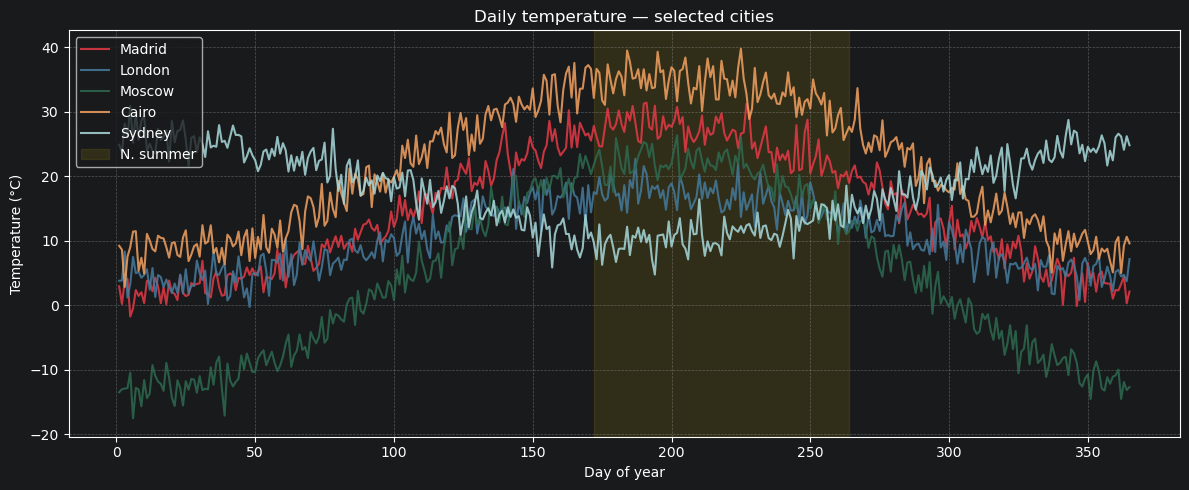

In [23]:
plot_cities = {
    "Madrid": "#e63946",
    "London": "#457b9d",
    "Moscow": "#2d6a4f",
    "Cairo": "#f4a261",
    "Sydney": "#a8dadc",
}

fig, ax = plt.subplots(figsize=(12, 5))

for city, color in plot_cities.items():
    v = climate.where(climate.city == city)
    d = v.day[:].astype(int)
    t = v["temperature"][:]
    order = np.argsort(d)
    ax.plot(d[order], t[order], label=city, color=color, linewidth=1.5, alpha=0.85)

ax.axvspan(SUMMER_START, SUMMER_END, alpha=0.10, color="gold", label="N. summer")
ax.set_xlabel("Day of year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Daily temperature — selected cities")
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 5.2 Summer temperature distribution — Madrid vs London

A simple histogram comparison of how often each city exceeds different temperature thresholds.

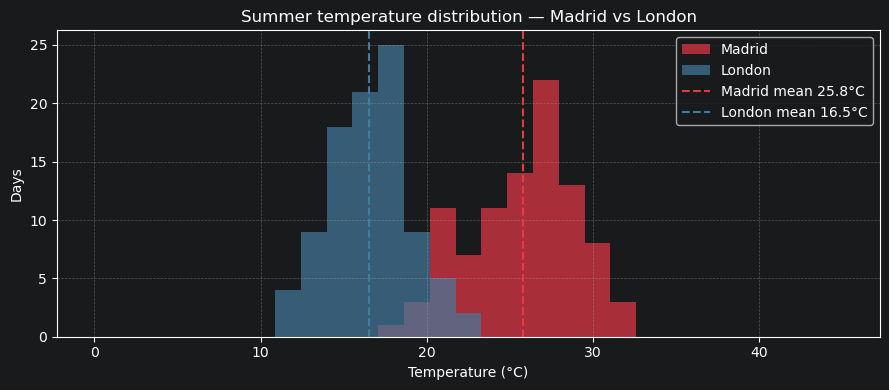

In [24]:
madrid_s = climate.where(
    (climate.city == "Madrid") & (climate.day >= SUMMER_START) & (climate.day <= SUMMER_END)
)["temperature"][:]

london_s = climate.where(
    (climate.city == "London") & (climate.day >= SUMMER_START) & (climate.day <= SUMMER_END)
)["temperature"][:]

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 45, 30)
ax.hist(madrid_s, bins=bins, alpha=0.7, color="#e63946", label="Madrid")
ax.hist(london_s, bins=bins, alpha=0.7, color="#457b9d", label="London")
ax.axvline(
    madrid_s.mean(),
    color="#e63946",
    linestyle="--",
    linewidth=1.5,
    label=f"Madrid mean {madrid_s.mean():.1f}°C",
)
ax.axvline(
    london_s.mean(),
    color="#457b9d",
    linestyle="--",
    linewidth=1.5,
    label=f"London mean {london_s.mean():.1f}°C",
)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Days")
ax.set_title("Summer temperature distribution — Madrid vs London")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 5.3 Mean summer temperature — all cities ranked

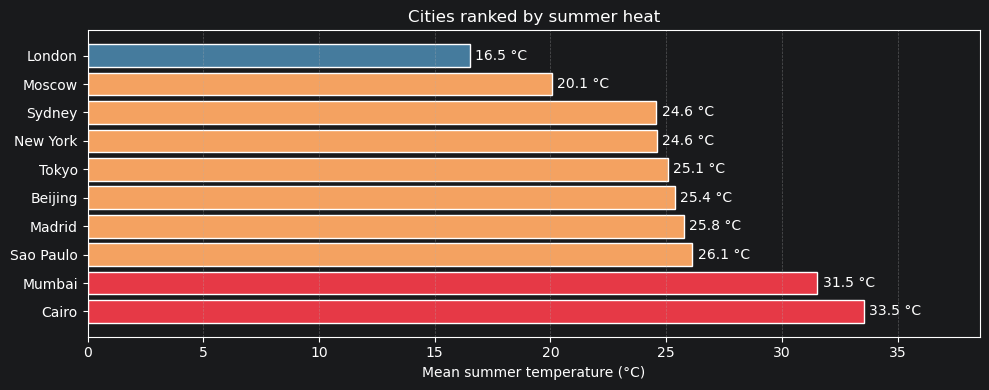

In [25]:
city_summer_means = {}
for city in CITY_PROFILES:
    v = climate.where(climate.city == city)
    if city == "Sydney" or city == "Sao Paulo":
        s = v.where((v.day <= 80) | (v.day >= 355))
    else:
        s = v.where((v.day >= SUMMER_START) & (v.day <= SUMMER_END))
    city_summer_means[city] = s["temperature"].mean()

sorted_cities = sorted(city_summer_means.items(), key=lambda x: x[1], reverse=True)
names = [c for c, _ in sorted_cities]
means = [m for _, m in sorted_cities]
colors = ["#e63946" if m > 30 else "#f4a261" if m > 20 else "#457b9d" for m in means]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(names, means, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.1f °C", padding=4)
ax.set_xlabel("Mean summer temperature (°C)")
ax.set_title("Cities ranked by summer heat")
ax.set_xlim(0, max(means) * 1.15)
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 5.4 Group-by aggregation (new in 4.3.0)

Instead of looping per city, you can use `CTable.group_by()` to compute
per-group statistics in a single call.  The result is a new `CTable` with
one row per group.  Both single aggregations and multi-column summaries are
supported:


In [26]:
# Get summer data for northern-hemisphere cities
north_summer = climate.where((climate.day >= SUMMER_START) & (climate.day <= SUMMER_END))

# Mean temperature per city — one line, no loop
by_city = north_summer.group_by("city", sort=True)
print(by_city.mean("temperature"))

        city  temperature_mean
0    Beijing         25.373933
1      Cairo         33.528195
2     London         16.518385
3     Madrid         25.756464
4     Moscow         20.057594
5     Mumbai         31.515763
6   New York         24.598771
7  Sao Paulo         17.291734
8     Sydney         11.200859
9      Tokyo         25.069180


In [27]:
# Or multiple aggregations at once
print(by_city.agg({"temperature": ["mean", "max"], "humidity": "mean"}))

        city  temperature_mean  temperature_max  humidity_mean
0    Beijing         25.373933        33.777534      55.636206
1      Cairo         33.528195        39.747101      34.370548
2     London         16.518385        22.690062      74.554782
3     Madrid         25.756464        31.399208      43.788414
4     Moscow         20.057594        26.334589      69.326794
5     Mumbai         31.515763        36.623379      81.086226
6   New York         24.598771        30.867567      63.924396
7  Sao Paulo         17.291734        22.889439      76.320440
8     Sydney         11.200859        18.521643      63.879595
9      Tokyo         25.069180        30.971607      73.002207


---
## Part 6 — Mutations

CTable supports structural and value mutations: adding/dropping columns, deleting rows, sorting in place.

In [28]:
# Add a 'feels_like' column: temperature adjusted for wind chill (simplified)
climate.add_column("feels_like", blosc2.field(blosc2.float32(), default=0.0))

temp = climate.temperature[:]
wind = climate["wind_speed"][:]
# Simple wind-chill approximation (only meaningful below 10°C)
feels = np.where(temp < 10, temp - wind * 0.15, temp).astype(np.float32)
climate["feels_like"].assign(feels)

print("Table with feels_like column:")
print(climate.head(5))
print(f"\nColdest 'feels like' day: {climate['feels_like'].min():.1f} °C")

Table with feels_like column:
     city  day  temperature   humidity  wind_speed     pressure  feels_like
0  Madrid    1     2.909234  56.851643   14.764506  1014.201111    0.694558
1  Madrid    2     0.173933  39.051292   12.571674  1017.437012   -1.711819
2  Madrid    3     3.712682  38.422001   12.351028  1008.641602    1.860027
3  Madrid    4     4.054576  46.618450   14.671753  1004.238770    1.853813
4  Madrid    5    -1.763155  51.755081   18.278116  1008.797791   -4.504872

Coldest 'feels like' day: -19.2 °C


---
## Part 7 — Persistence

CTable can live on disk in two Blosc2 container formats:

- `.b2d`: a directory-backed store. This is the best default for local read/write workflows.
- `.b2z`: a single zip-backed store. This is compact and convenient for sharing or archiving, and is typically opened read-only.

Both formats keep the table columns compressed. Use `open()` for persistent/on-disk access and `load()` when you want an in-memory copy.


In [29]:
import os
import shutil
import tempfile

tmpdir = tempfile.mkdtemp(prefix="blosc2_climate_")
disk_path = f"{tmpdir}/climate.b2d"
zip_path = f"{tmpdir}/climate.b2z"
unpacked_path = f"{tmpdir}/climate-unpacked.b2d"
compact_zip_path = f"{tmpdir}/climate-compact.b2z"

# Save the in-memory table to a directory-backed .b2d store
climate.save(disk_path)
print(f"Saved to '{disk_path}'")

total_kb = sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(disk_path) for f in fs) / 1024
print(f"On-disk size: {total_kb:.1f} KB")
print(f"In-memory compressed: {climate.cbytes / 1024:.1f} KB")

Saved to '/var/folders/tb/7hwq2y354bb_68xwxjwjwwlr0000gn/T/blosc2_climate_xsqe_hx3/climate.b2d'
On-disk size: 56.0 KB
In-memory compressed: 53.4 KB


### Fast conversion between `.b2d` and `.b2z`

`to_b2z()` and `to_b2d()` use fast physical pack/unpack paths when possible: already-compressed leaves are copied as-is, without recompressing columns. This preserves the physical layout, including deleted rows and spare capacity.

Use `compact=True` when you want a logical compacted copy containing only visible/live rows. That path may rewrite columns and is slower.


In [30]:
# Fast-pack .b2d -> .b2z
ro = CTable.open(disk_path, mode="r")
ro.to_b2z(zip_path, overwrite=True)
ro.close()
print(f"Packed into '{zip_path}'")

# Fast-unpack .b2z -> .b2d
zipped = CTable.open(zip_path, mode="r")
zipped.to_b2d(unpacked_path, overwrite=True)
zipped.close()
print(f"Unpacked into '{unpacked_path}'")

# Logical compacted copy
ro = CTable.open(disk_path, mode="r")
ro.to_b2z(compact_zip_path, overwrite=True, compact=True)
ro.close()
print(f"Compacted copy: '{compact_zip_path}'")

Packed into '/var/folders/tb/7hwq2y354bb_68xwxjwjwwlr0000gn/T/blosc2_climate_xsqe_hx3/climate.b2z'
Unpacked into '/var/folders/tb/7hwq2y354bb_68xwxjwjwwlr0000gn/T/blosc2_climate_xsqe_hx3/climate-unpacked.b2d'
Compacted copy: '/var/folders/tb/7hwq2y354bb_68xwxjwjwwlr0000gn/T/blosc2_climate_xsqe_hx3/climate-compact.b2z'


In [31]:
# Open read-only — fast, no data is copied until you access a column
ro = CTable.open(disk_path, mode="r")
print(f"Opened read-only: {len(ro):,} rows")
print(f"Cairo annual mean: {ro.where(ro.city == 'Cairo').temperature.mean():.1f} °C")
ro.close()

# Load fully into RAM (useful when you need repeated random access)
ram = CTable.load(disk_path)
print(f"Loaded into RAM : {len(ram):,} rows")

shutil.rmtree(tmpdir)
print("Temporary files removed.")

Opened read-only: 3,650 rows
Cairo annual mean: 21.9 °C
Loaded into RAM : 3,650 rows
Temporary files removed.


---
## Part 8 — Arrow & CSV interop

CTable speaks Arrow and CSV, so it fits naturally into data pipelines.

In [32]:
# CTable → Arrow
arrow_table = climate.select(["city", "day", "temperature"]).to_arrow()
print("Arrow table schema:", arrow_table.schema)
print("First 3 rows:", arrow_table.slice(0, 3).to_pydict())

Arrow table schema: city: string
day: int16
temperature: float
First 3 rows: {'city': ['Madrid', 'Madrid', 'Madrid'], 'day': [1, 2, 3], 'temperature': [2.909233808517456, 0.17393270134925842, 3.712681531906128]}


In [33]:
import os
import tempfile

# CTable → CSV → CTable round-trip
tmp_csv = tempfile.mktemp(suffix=".csv")
climate.select(["city", "day", "temperature", "humidity"]).to_csv(tmp_csv)

print(f"CSV size: {os.path.getsize(tmp_csv) / 1024:.1f} KB")


@dataclass
class SlimReading:
    city: str = blosc2.field(blosc2.string(max_length=16))
    day: int = blosc2.field(blosc2.int16(ge=1, le=365), default=1)
    temperature: float = blosc2.field(blosc2.float32(), default=0.0)
    humidity: float = blosc2.field(blosc2.float32(), default=0.0)


t_from_csv = CTable.from_csv(tmp_csv, SlimReading)
print(f"Loaded from CSV: {len(t_from_csv):,} rows")
os.remove(tmp_csv)

CSV size: 111.5 KB
Loaded from CSV: 3,650 rows


### 8.3 Zero-copy Arrow interchange (new in 4.9.0)

`to_arrow()`/`from_arrow()` above go through a full `pyarrow.Table` copy. The Arrow **PyCapsule interchange protocol**
skips that step: `CTable.__arrow_c_stream__` lets any tool that speaks the protocol — pyarrow, DuckDB, Polars —
read a `CTable` directly as a stream of record batches, with bounded memory. pandas >= 3.0 gets the same treatment
via the new `pandas.DataFrame.from_arrow(t)` classmethod (the plain `pd.DataFrame(t)` constructor does not use this protocol).

In [34]:
import pyarrow as pa

slim = climate.select(["city", "day", "temperature"])

# pyarrow reads the CTable directly — no to_arrow() copy needed
at_direct = pa.table(slim)
print("pa.table(slim) schema:", at_direct.schema)

# CTable.from_arrow() accepts any Arrow-stream object directly (not just
# a (schema, batches) pair) -- a pyarrow Table, a Polars DataFrame, etc.
back = CTable.from_arrow(at_direct)
print(f"round-tripped: {len(back):,} rows")

pa.table(slim) schema: city: string
day: int16
temperature: float
round-tripped: 3,650 rows


---
## Part 9 — Nullable columns

Real-world data is often incomplete. CTable handles missing values through a **null sentinel** approach: you declare a specific value (e.g. `-1`, `""`, or `float("nan")`) that represents "no data" for a column. The library treats it transparently in aggregates, sorting, `unique()`, `value_counts()`, and Arrow export.

This pattern is most useful for **integer and string** columns, which have no natural missing-value representation (unlike floats, which can use `NaN`).

In [35]:
from dataclasses import dataclass


# Sensor log where some readings may be missing
@dataclass
class SensorLog:
    sensor_id: int = blosc2.field(blosc2.int32(ge=0))
    # -999 means "offline" — bypasses the ge/le constraint when stored
    temperature: float = blosc2.field(blosc2.float64(ge=-50.0, le=60.0, null_value=-999.0), default=-999.0)
    # "" means "location unknown"
    location: str = blosc2.field(blosc2.string(max_length=16, null_value=""), default="")


log_data = [
    (0, 22.3, "roof"),
    (1, -999.0, "cellar"),  # temperature: offline
    (2, 18.7, ""),  # location: unknown
    (3, 31.5, "garage"),
    (4, -999.0, ""),  # both missing
    (5, 15.1, "roof"),
]

log = blosc2.CTable(SensorLog, new_data=log_data)
print(log)

   sensor_id  temperature  location
0          0    22.300000      roof
1          1  -999.000000    cellar
2          2    18.700000          
3          3    31.500000    garage
4          4  -999.000000          
5          5    15.100000      roof


### 9.1 Detecting nulls

In [36]:
# is_null() → boolean array aligned to live rows
print("temperature is_null:", log["temperature"].is_null().tolist())
print("location is_null   :", log["location"].is_null().tolist())
print()
print(f"Offline sensors (null temperature): {log.temperature.null_count()}")
print(f"Unknown locations                 : {log['location'].null_count()}")

# Use notnull() as a mask to select only valid readings
valid_temps = log["temperature"][:][log["temperature"].notnull()]
print(f"Valid temperature readings: {valid_temps}")

temperature is_null: [False, True, False, False, True, False]
location is_null   : [False, False, True, False, True, False]

Offline sensors (null temperature): 2
Unknown locations                 : 2
Valid temperature readings: [22.3 18.7 31.5 15.1]


### 9.2 Null-aware aggregates

In [37]:
# All aggregates automatically skip the null sentinel
temp = log["temperature"]
print(f"mean  = {temp.mean():.2f}  (3 valid readings only)")
print(f"min   = {temp.min():.2f}")
print(f"max   = {temp.max():.2f}")
print()
# unique() and value_counts() also exclude the sentinel
print("location unique:", log["location"].unique().tolist())

mean  = 21.90  (3 valid readings only)
min   = 15.10
max   = 31.50

location unique: ['cellar', 'garage', 'roof']


### 9.3 Validation bypass

In [38]:
# The sentinel bypasses ge/le constraints — you can store it freely
# even though -999.0 is below ge=-50.0
log.append((6, -999.0, "attic"))  # succeeds: -999 is the null sentinel
print(f"Rows after append: {len(log)}")

# A genuine constraint violation still raises:
try:
    log.append((7, -100.0, "lab"))  # -100 is NOT the sentinel → rejected
except ValueError:
    print("Rejected: temperature -100 violates ge=-50")

Rows after append: 7
Rejected: temperature -100 violates ge=-50


### 9.4 Sort: nulls always go last

In [39]:
# Regardless of ascending / descending, null rows are placed at the end
s = log.sort_by("temperature")
print("Ascending (nulls last):")
print([round(v, 1) for v in s["temperature"][:].tolist()])

s_desc = log.sort_by("temperature", ascending=False)
print("Descending (nulls still last):")
print([round(v, 1) for v in s_desc["temperature"][:].tolist()])

Ascending (nulls last):
[15.1, 18.7, 22.3, 31.5, -999.0, -999.0, -999.0]
Descending (nulls still last):
[31.5, 22.3, 18.7, 15.1, -999.0, -999.0, -999.0]


### 9.5 Arrow export: sentinels become Arrow nulls

In [40]:
try:
    arrow = log.to_arrow()
    tc = arrow.column("temperature")
    lc = arrow.column("location")
    print(f"Arrow temperature null_count: {tc.null_count}")
    print(f"Arrow location null_count   : {lc.null_count}")
    print("Arrow temperature values:", tc.to_pylist())
except Exception as e:
    print(f"(pyarrow not available: {e})")

Arrow temperature null_count: 3
Arrow location null_count   : 2
Arrow temperature values: [22.3, None, 18.7, 31.5, None, 15.1, None]


### 9.6 CSV: empty cells become the null sentinel

In [41]:
import os
import tempfile

csv_content = """sensor_id,temperature,location
10,25.1,lab
11,,office
12,18.3,
"""

with tempfile.NamedTemporaryFile(mode="w", suffix=".csv", delete=False) as f:
    f.write(csv_content)
    csv_path = f.name

log2 = blosc2.CTable.from_csv(csv_path, SensorLog)
print(log2)
print(f"temperature null_count: {log2.temperature.null_count()}")
print(f"location null_count   : {log2['location'].null_count()}")
os.unlink(csv_path)

   sensor_id  temperature  location
0         10    25.100000       lab
1         11  -999.000000    office
2         12    18.300000          
temperature null_count: 1
location null_count   : 1


### 9.7 `fillna()` and `dropna()` (new in 4.9.0)

Beyond detecting nulls, `Column.fillna(value)` replaces sentinel values with a given value (returning a plain array),
and `CTable.dropna(subset=None)` returns a **view** excluding any row where a nullable column (or a chosen subset) is null.

In [42]:
# fillna(): replace sentinel values in one column
print("temperature, filled:", log["temperature"].fillna(0.0))
print("location, filled   :", log["location"].fillna("<unknown>"))

# dropna(): drop rows with any null (or restrict to a subset)
complete = log.dropna()
print(f"\ncomplete rows (no nulls anywhere): {len(complete)} / {len(log)}")

only_missing_location = log.dropna(subset=["location"])
print(f"rows with known location        : {len(only_missing_location)} / {len(log)}")

temperature, filled: [22.3  0.  18.7 31.5  0.  15.1  0. ]
location, filled   : ['roof' 'cellar' '<unknown>' 'garage' '<unknown>' 'roof' 'attic']

complete rows (no nulls anywhere): 3 / 7
rows with known location        : 5 / 7


---
## Part 10 — String column types (new in 4.9.0)

CTable offers four ways to store strings, each with a different tradeoff:

| | `string()` | `utf8()` | `dictionary()` | `vlstring()` |
|---|---|---|---|---|
| Best for | short, near-uniform codes; indexed columns | general text (names, descriptions, high-cardinality) | low-cardinality categories | NumPy < 2.0, or nullable columns needing native `None` |
| Storage | fixed-width UTF-32 | int64 offsets + UTF-8 bytes (Arrow-style) | integer codes + unique values | msgpack batches |
| Per-row cost | `4 × max_length` bytes | exact UTF-8 length + 8 bytes | one integer code | value + msgpack framing |
| Filters / sort / groupby | fast, vectorized | vectorized (comparisons, `sort_by`, `group_by` keys) | fast (works on codes) | slow |
| `create_index()` | yes | not yet | yes | no |

`utf8()` is the new recommended default for free text: no `max_length` to guess, no truncation, and it plugs into the same query
surface as any other column — while storing data in the same layout Arrow uses for `large_string`, so Arrow/pandas/DuckDB
export it and read it back natively.

In [43]:
@dataclass
class Place:
    # utf8 is never inferred from a plain `str` annotation (that still maps
    # to fixed-width string(max_length=32)); request it explicitly.
    name: str = blosc2.field(blosc2.utf8())
    note: str = blosc2.field(blosc2.utf8(nullable=True))
    visitors: int = blosc2.field(blosc2.int64())


places = blosc2.CTable(
    Place,
    new_data={
        "name": ["café", "O'Hare", "日本語のテキスト", "zürich", "Sao Paulo"],
        "note": ["cozy", None, "multi-byte ok", None, "big city"],
        "visitors": [120, 85_000, 42, 300, 61_000],
    },
)
print(f"name dtype: {places['name'].dtype}")

# Comparisons, sort_by, and group_by keys work directly on utf8 columns
print("\nexact match:", places[places.name == "café"].nrows, "row(s)")
print("\nsorted by name (multi-byte values sort by Unicode code point):")
print(places.sort_by("name")[["name", "visitors"]])

name dtype: StringDType()

exact match: 1 row(s)

sorted by name (multi-byte values sort by Unicode code point):
        name  visitors
0     O'Hare     85000
1  Sao Paulo     61000
2       café       120
3     zürich       300
4   日本語のテキスト        42


In [44]:
# utf8 nulls are sentinel-based (like other scalar columns), so is_null()/fillna() work the same way
print("note is_null:", list(places["note"].is_null()))
print("note filled :", list(places["note"].fillna("<no note>")))

# utf8 columns work as group_by() keys, same as any other key type
by_name = places.group_by("name", sort=True)
print("\nvisitors per name:")
print(by_name.sum("visitors"))

# Arrow export uses large_string natively, and re-import maps back to utf8()
at = places.to_arrow()
print(f"\nArrow export: name -> {at.schema.field('name').type}")
places2 = CTable.from_arrow(at)
print(f"round-trip dtype: {places2['name'].dtype}")

note is_null: [np.False_, np.True_, np.False_, np.True_, np.False_]
note filled : ['cozy', '<no note>', 'multi-byte ok', '<no note>', 'big city']

visitors per name:
        name  visitors_sum
0     O'Hare         85000
1  Sao Paulo         61000
2       café           120
3     zürich           300
4   日本語のテキスト            42

Arrow export: name -> large_string
round-trip dtype: StringDType()


---
## Summary

Here's everything we covered:

| Feature | API |
|---------|-----|
| Create | `CTable(Schema)`, `CTable(Schema, new_data=...)` |
| Insert | `append(row)`, `extend(list_or_array)` |
| View | `head()`, `tail()`, `print(t)`, `t.info()` |
| Filter | `where(expr)` → view |
| Project | `select([cols])` → view |
| Sort | `sort_by(cols)`, `sort_by(cols, view=True)`, `sort_by(cols, inplace=True)` |
| Aggregates | `col.sum()`, `.mean()`, `.std()`, `.min()`, `.max()` |
| Stats | `describe()`, `cov()` |
| Mutate | `delete()`, `compact()`, `add_column()`, `drop_column()`, `assign()` (column value) |
| Chaining | `CTable.assign(**exprs)` + `blosc2.col(name)` — pandas-3-style query chains |
| Persist | `save(path)`, `to_b2z()`, `to_b2d()`, `CTable.open(path)`, `CTable.load(path)` |
| Interop | `to_arrow()`, `from_arrow()`, `to_csv()`, `from_csv()`, zero-copy `__arrow_c_stream__` |
| Nullable | `null_value=` on spec, `is_null()`, `notnull()`, `null_count()`, `fillna()`, `dropna()` |
| String columns | `string()` (fixed-width), `utf8()` (Arrow-style, recommended default), `dictionary()`, `vlstring()` |

CTable is designed for **compressed analytical workloads** — large tables that need to stay small in RAM
while still being fast to query and easy to persist.